# MATA KULIAH DATA MINING

## UAS ESTIMASI DATA MINING

### Estimasi Total Pembayaran pada Dataset E-Commerce Indonesia Menggunakan Metode Random Forest Regression
---

 ### Disusun Oleh

| Keterangan | Data |
|------------|------|
| Nama | Silvy Khovifah |
| NIM | 1224160103 |
| Kelas | SI24-P SIM 2 |

---



# Phase 1 Business Understanding

## Latar Belakang

E-commerce merupakan salah satu sektor yang mengalami perkembangan pesat di Indonesia. Setiap transaksi yang terjadi menghasilkan berbagai informasi seperti jumlah barang yang dibeli, berat barang, metode pembayaran, diskon, ongkos kirim, dan total pembayaran.

Data transaksi tersebut dapat dimanfaatkan untuk memperoleh informasi yang berguna dalam pengambilan keputusan bisnis serta memahami faktor-faktor yang mempengaruhi nilai transaksi pelanggan.

Dengan memanfaatkan teknik data mining, data transaksi dapat diolah menjadi informasi yang lebih bernilai sehingga dapat membantu perusahaan dalam melakukan analisis penjualan dan perilaku pelanggan.

## Tujuan Analisis

Tujuan penelitian ini adalah menganalisis faktor-faktor yang mempengaruhi Total Pembayaran pada dataset E-Commerce Indonesia.

Analisis dilakukan untuk memahami hubungan antara berbagai variabel transaksi dengan Total Pembayaran serta membangun model estimasi yang mampu memprediksi Total Pembayaran secara akurat.

## Tujuan Data Mining

Metode yang digunakan dalam penelitian ini adalah Random Forest Regression untuk melakukan estimasi Total Pembayaran berdasarkan berbagai variabel transaksi pelanggan.

Model yang dibangun diharapkan mampu menghasilkan prediksi yang akurat sehingga dapat membantu proses analisis dan pengambilan keputusan bisnis.

## Manfaat Analisis

Manfaat dari analisis ini adalah:

- Mengetahui faktor-faktor yang mempengaruhi Total Pembayaran pelanggan.
- Membantu memahami pola transaksi pada platform e-commerce.
- Mendukung proses pengambilan keputusan berbasis data.
- Menghasilkan model estimasi yang dapat digunakan untuk memprediksi Total Pembayaran transaksi pelanggan.

# Phase 2 Data Understanding

## Pemahaman Data

Pada tahap ini dilakukan eksplorasi terhadap dataset E-Commerce Indonesia untuk memahami karakteristik data yang akan digunakan dalam proses analisis.

Tahapan yang dilakukan meliputi:

- Membaca dataset
- Menampilkan informasi dataset
- Melihat statistik deskriptif
- Memeriksa missing value
- Memeriksa data duplikat
- Menganalisis korelasi antar variabel
- Membuat visualisasi data

Tahap ini bertujuan untuk mengetahui kualitas data serta memahami hubungan antar variabel sebelum dilakukan proses pemodelan.

## Sumber Dataset

Dataset diperoleh dari Kaggle.

Link Dataset:

https://www.kaggle.com/datasets/zkyfauzi/indonesia-ecommerce-sales

## Insight Data Understanding

Berdasarkan hasil eksplorasi data diperoleh beberapa informasi penting sebagai berikut:

- Dataset terdiri dari ribuan transaksi e-commerce yang mencakup berbagai informasi transaksi pelanggan.
- Tidak ditemukan missing value yang signifikan setelah proses pemeriksaan data.
- Tidak ditemukan data duplikat yang mempengaruhi proses analisis.
- Variabel Total Pembayaran memiliki hubungan dengan beberapa variabel transaksi seperti jumlah barang, berat barang, diskon, dan ongkos kirim.
- Dataset memiliki kualitas yang baik dan layak digunakan dalam proses pemodelan data mining.

Tahap Data Understanding memberikan gambaran awal mengenai karakteristik data sehingga dapat digunakan sebagai dasar dalam proses persiapan data dan pembangunan model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format','{:.2f}'.format)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [2]:
df = pd.read_csv('indonesia_ecommerce_sales_challenging.csv', sep=';')

df

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,order_date
0,ORD_0000001,2.00,2000,0,0,Celengan,1,Selesai,Tidak dibatalkan,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,2024-04-01
1,ORD_0000002,1.00,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,2024-04-01
2,ORD_0000003,1.00,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,2024-04-01
3,ORD_0000004,2.00,400,0,0,Mangkok Sambal / Saus,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,2024-04-01
4,ORD_0000005,3.00,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,2024-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18863,ORD_0020844,2.00,200,0,0,Seal / Baut / Roof,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,Online Payment,KAB. BOGOR,JAWA BARAT,0,3500,37500,3500,2025-09-30 21:30,2025-09-30
18864,ORD_0020845,2.00,160,0,0,Aksesoris Pintu,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KAB. KARAWANG,JAWA BARAT,0,3500,15000,3500,2025-09-30 21:35,2025-09-30
18865,ORD_0020846,1.00,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,SPayLater,KOTA BANDAR LAMPUNG,LAMPUNG,1000,15000,20000,16000,2025-09-30 22:33,2025-09-30
18866,ORD_0020847,1.00,80,0,0,Aksesoris Pintu,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,SPayLater,KOTA BANDUNG,JAWA BARAT,0,3500,9000,3500,2025-09-30 23:39,2025-09-30


In [3]:
print("=== DATASET BERHASIL DILOAD ===")
print(f"Jumlah Baris (Observasi) : {df.shape[0]}")
print(f"Jumlah Kolom (Variabel) : {df.shape[1]}")

print("\nDataset:")
display(df)

=== DATASET BERHASIL DILOAD ===
Jumlah Baris (Observasi) : 18868
Jumlah Kolom (Variabel) : 19

Dataset:


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,order_date
0,ORD_0000001,2.00,2000,0,0,Celengan,1,Selesai,Tidak dibatalkan,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,2024-04-01
1,ORD_0000002,1.00,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,2024-04-01
2,ORD_0000003,1.00,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,2024-04-01
3,ORD_0000004,2.00,400,0,0,Mangkok Sambal / Saus,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,2024-04-01
4,ORD_0000005,3.00,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,2024-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18863,ORD_0020844,2.00,200,0,0,Seal / Baut / Roof,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,Online Payment,KAB. BOGOR,JAWA BARAT,0,3500,37500,3500,2025-09-30 21:30,2025-09-30
18864,ORD_0020845,2.00,160,0,0,Aksesoris Pintu,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KAB. KARAWANG,JAWA BARAT,0,3500,15000,3500,2025-09-30 21:35,2025-09-30
18865,ORD_0020846,1.00,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,SPayLater,KOTA BANDAR LAMPUNG,LAMPUNG,1000,15000,20000,16000,2025-09-30 22:33,2025-09-30
18866,ORD_0020847,1.00,80,0,0,Aksesoris Pintu,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,SPayLater,KOTA BANDUNG,JAWA BARAT,0,3500,9000,3500,2025-09-30 23:39,2025-09-30


In [4]:
print("\n=== INFORMASI LENGKAP DATASET ===")
df.info()


=== INFORMASI LENGKAP DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18868 entries, 0 to 18867
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   order_id                            18868 non-null  object 
 1   total_qty                           18585 non-null  float64
 2   total_weight_gr                     18868 non-null  int64  
 3   total_returned_qty                  18868 non-null  int64  
 4   Total Diskon                        18868 non-null  int64  
 5   product_categories                  18868 non-null  object 
 6   num_product_categories              18868 non-null  int64  
 7   Status Pesanan                      18868 non-null  object 
 8   Alasan Pembatalan                   18868 non-null  object 
 9   Opsi Pengiriman                     18868 non-null  object 
 10  Metode Pembayaran                   18585 non-null  object 
 11  Kota/K

In [5]:
print("\n=== STATISTIK DESKRIPTIF (Numerik) ===")
display(df.describe())


=== STATISTIK DESKRIPTIF (Numerik) ===


,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim
count,18585.00,18868.00,18868.00,18868.00,18868.00,18868.00,18868.00,18868.00,18868.00
mean,2.57,2021.27,0.02,424.22,1.11,4312.36,10605.74,50990.66,18446.54
std,7.80,7044.93,0.58,10110.49,0.49,13900.86,12482.33,142618.93,23076.10
min,1.00,10.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,1.00,300.00,0.00,0.00,1.00,0.00,0.00,13675.00,8000.00
50%,1.00,500.00,0.00,0.00,1.00,0.00,9000.00,21800.00,11000.00
75%,2.00,1600.00,0.00,0.00,1.00,3000.00,15000.00,42311.25,20000.00
max,256.00,375000.00,70.00,700000.00,11.00,584000.00,312000.00,3076000.00,624000.00


In [6]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
order_id                                0
total_qty                             283
total_weight_gr                         0
total_returned_qty                      0
Total Diskon                            0
product_categories                      0
num_product_categories                  0
Status Pesanan                          0
Alasan Pembatalan                       0
Opsi Pengiriman                         0
Metode Pembayaran                     283
Kota/Kabupaten                          0
Provinsi                                0
Ongkos Kirim Dibayar oleh Pembeli       0
Estimasi Potongan Biaya Pengiriman      0
Total Pembayaran                        0
Perkiraan Ongkos Kirim                  0
Waktu Pesanan Dibuat                    0
order_date                            188
dtype: int64


In [7]:
print("\n=== JUMLAH DATA DUPLIKAT ===")
print(df.duplicated().sum())


=== JUMLAH DATA DUPLIKAT ===
0


In [8]:
print("\n=== MATRIKS KORELASI PEARSON ===" )

num_cols = [
    'total_qty',
    'total_weight_gr',
    'total_returned_qty',
    'Total Diskon',
    'num_product_categories',
    'Perkiraan Ongkos Kirim',
    'Ongkos Kirim Dibayar oleh Pembeli',
    'Estimasi Potongan Biaya Pengiriman',
    'Total Pembayaran'
]

correlation_matrix = df[num_cols].corr()

display(correlation_matrix)


=== MATRIKS KORELASI PEARSON ===


,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Perkiraan Ongkos Kirim,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran
total_qty,1.00,0.46,0.12,0.73,0.09,0.37,0.23,0.20,0.31
total_weight_gr,0.46,1.00,0.09,0.21,0.34,0.40,0.22,0.21,0.38
total_returned_qty,0.12,0.09,1.00,-0.00,0.03,0.03,0.03,0.01,0.03
Total Diskon,0.73,0.21,-0.00,1.00,-0.01,0.22,0.17,0.11,0.23
num_product_categories,0.09,0.34,0.03,-0.01,1.00,0.06,0.02,0.07,0.03
Perkiraan Ongkos Kirim,0.37,0.40,0.03,0.22,0.06,1.00,0.65,0.52,0.49
Ongkos Kirim Dibayar oleh Pembeli,0.23,0.22,0.03,0.17,0.02,0.65,1.00,0.17,0.45
Estimasi Potongan Biaya Pengiriman,0.20,0.21,0.01,0.11,0.07,0.52,0.17,1.00,0.50
Total Pembayaran,0.31,0.38,0.03,0.23,0.03,0.49,0.45,0.50,1.00


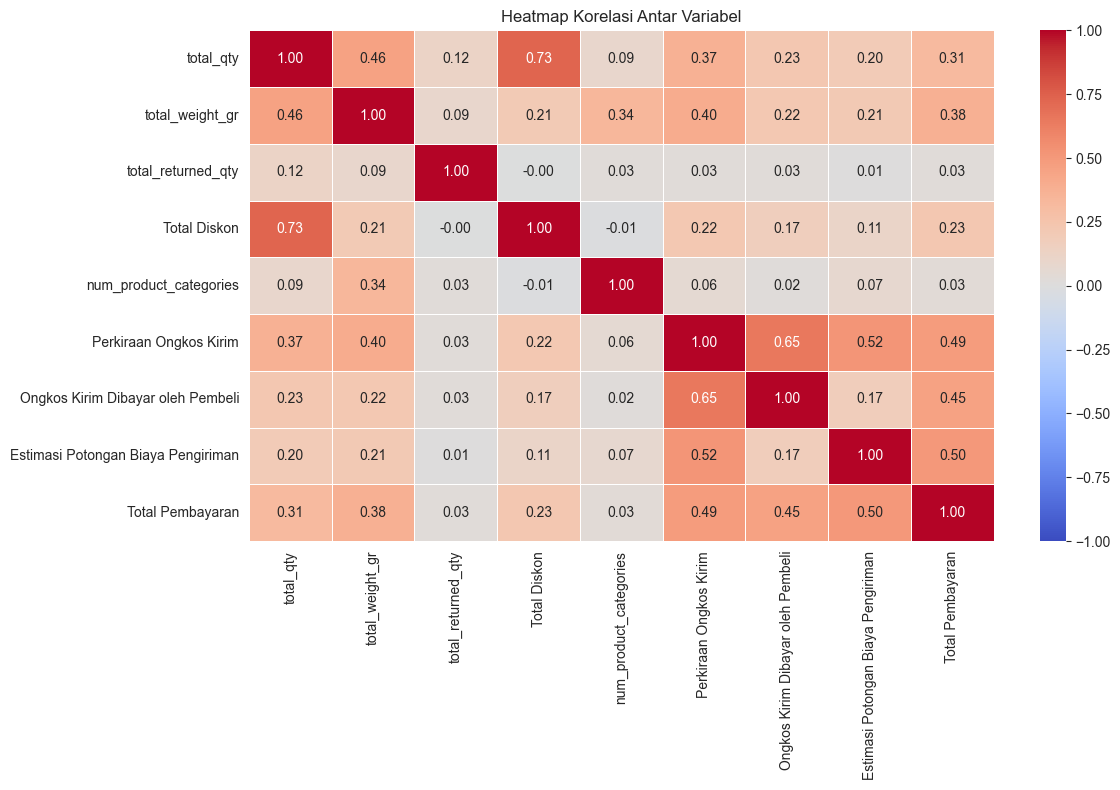

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            fmt='.2f',
            annot_kws={'size':10})

plt.title('Heatmap Korelasi Antar Variabel')

plt.tight_layout()
plt.show()

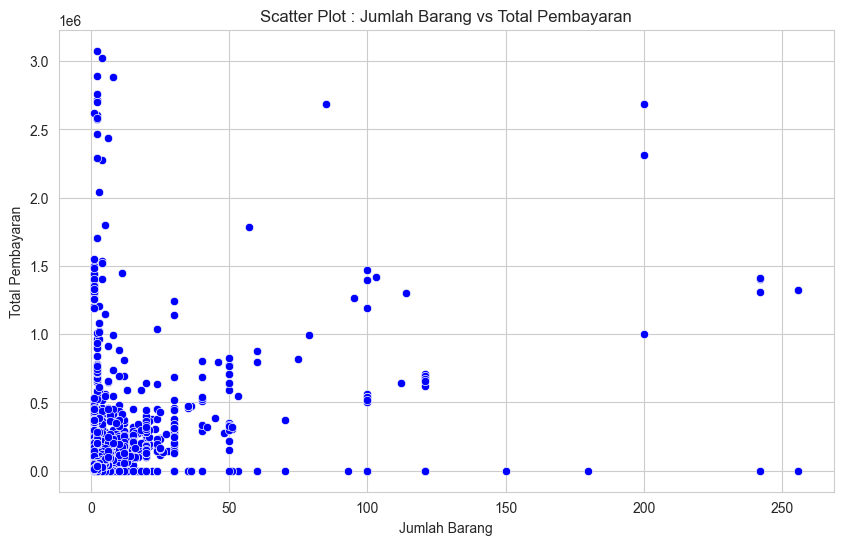

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='total_qty',
    y='Total Pembayaran',
    color='blue'
)

plt.title('Scatter Plot : Jumlah Barang vs Total Pembayaran')
plt.xlabel('Jumlah Barang')
plt.ylabel('Total Pembayaran')

plt.grid(True)
plt.show()

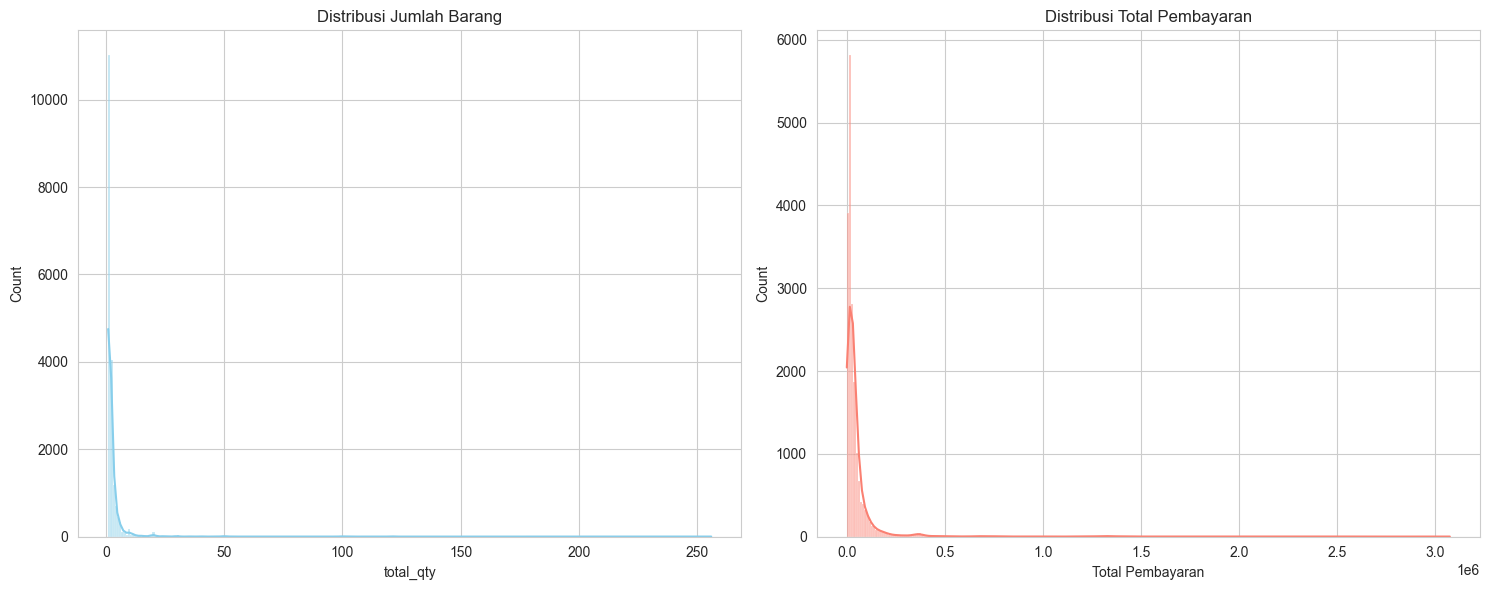

In [11]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['total_qty'],
             kde=True,
             ax=axes[0],
             color='skyblue')

axes[0].set_title('Distribusi Jumlah Barang')

sns.histplot(df['Total Pembayaran'],
             kde=True,
             ax=axes[1],
             color='salmon')

axes[1].set_title('Distribusi Total Pembayaran')

plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*70)
print("INSIGHT DARI DATA UNDERSTANDING:")
print("="*70)

print(f"- Total data observasi : {df.shape[0]} transaksi")
print(f"- Rata-rata jumlah barang : {df['total_qty'].mean():.2f}")
print(f"- Rata-rata total pembayaran : {df['Total Pembayaran'].mean():.2f}")
print(f"- Korelasi Jumlah Barang & Total Pembayaran : {df['total_qty'].corr(df['Total Pembayaran']):.4f}")
print(f"- Tidak ada missing value : {df.isnull().sum().sum() == 0}")
print(f"- Tidak ada data duplikat : {df.duplicated().sum() == 0}")

print("="*70)


INSIGHT DARI DATA UNDERSTANDING:
- Total data observasi : 18868 transaksi
- Rata-rata jumlah barang : 2.57
- Rata-rata total pembayaran : 50990.66
- Korelasi Jumlah Barang & Total Pembayaran : 0.3143
- Tidak ada missing value : False
- Tidak ada data duplikat : True


# Phase 3 Data Preparation

## Persiapan Data

Pada tahap ini dilakukan proses persiapan data sebelum membangun model estimasi. Tahap ini bertujuan untuk memastikan data yang digunakan memiliki kualitas yang baik dan siap diproses oleh algoritma machine learning.

Proses yang dilakukan meliputi:

- Pemeriksaan missing value
- Pembersihan data (data cleaning)
- Encoding variabel kategorikal
- Pemilihan variabel independen dan dependen

Variabel independen (X) yang digunakan dalam penelitian ini adalah:

- total_qty
- total_weight_gr
- total_returned_qty
- Total Diskon
- num_product_categories
- Perkiraan Ongkos Kirim
- Ongkos Kirim Dibayar oleh Pembeli
- Estimasi Potongan Biaya Pengiriman
- Status Pesanan
- Metode Pembayaran
- Provinsi

Variabel dependen (Y) yang digunakan adalah:

- Total Pembayaran

## Data Cleaning

Pada tahap ini dilakukan pengecekan missing value pada dataset. Data yang memiliki nilai kosong (missing value) dibersihkan menggunakan metode `dropna()` sehingga hanya data yang lengkap yang digunakan dalam proses pemodelan.

Langkah ini dilakukan untuk meningkatkan kualitas data dan mengurangi potensi kesalahan pada saat proses pelatihan model.

## Encoding Data

Karena terdapat beberapa variabel kategorikal, maka dilakukan proses encoding menggunakan Label Encoder agar data dapat diproses oleh algoritma machine learning.

Variabel yang dilakukan encoding meliputi:

- Status Pesanan
- Metode Pembayaran
- Provinsi

Hasil encoding mengubah data kategorikal menjadi bentuk numerik tanpa menghilangkan informasi yang terkandung di dalamnya.

## Seleksi Variabel

Setelah proses cleaning dan encoding selesai dilakukan, dipilih sejumlah variabel yang dianggap berpengaruh terhadap Total Pembayaran untuk digunakan sebagai input model.

Variabel-variabel tersebut kemudian digunakan sebagai data training dan data testing pada tahap pemodelan.

In [13]:
print("=== MISSING VALUE SEBELUM CLEANING ===")
print(df.isnull().sum())

=== MISSING VALUE SEBELUM CLEANING ===
order_id                                0
total_qty                             283
total_weight_gr                         0
total_returned_qty                      0
Total Diskon                            0
product_categories                      0
num_product_categories                  0
Status Pesanan                          0
Alasan Pembatalan                       0
Opsi Pengiriman                         0
Metode Pembayaran                     283
Kota/Kabupaten                          0
Provinsi                                0
Ongkos Kirim Dibayar oleh Pembeli       0
Estimasi Potongan Biaya Pengiriman      0
Total Pembayaran                        0
Perkiraan Ongkos Kirim                  0
Waktu Pesanan Dibuat                    0
order_date                            188
dtype: int64


In [14]:
df = df.dropna()

In [15]:
print("=== MISSING VALUE SETELAH CLEANING ===")
print(df.isnull().sum())

=== MISSING VALUE SETELAH CLEANING ===
order_id                              0
total_qty                             0
total_weight_gr                       0
total_returned_qty                    0
Total Diskon                          0
product_categories                    0
num_product_categories                0
Status Pesanan                        0
Alasan Pembatalan                     0
Opsi Pengiriman                       0
Metode Pembayaran                     0
Kota/Kabupaten                        0
Provinsi                              0
Ongkos Kirim Dibayar oleh Pembeli     0
Estimasi Potongan Biaya Pengiriman    0
Total Pembayaran                      0
Perkiraan Ongkos Kirim                0
Waktu Pesanan Dibuat                  0
order_date                            0
dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder

df = df.copy()

df.loc[:, 'Status Pesanan'] = LabelEncoder().fit_transform(
    df['Status Pesanan'].astype(str)
)

df.loc[:, 'Metode Pembayaran'] = LabelEncoder().fit_transform(
    df['Metode Pembayaran'].astype(str)
)

df.loc[:, 'Provinsi'] = LabelEncoder().fit_transform(
    df['Provinsi'].astype(str)
)

X = df[
    [
        'total_qty',
        'total_weight_gr',
        'total_returned_qty',
        'Total Diskon',
        'num_product_categories',
        'Perkiraan Ongkos Kirim',
        'Ongkos Kirim Dibayar oleh Pembeli',
        'Estimasi Potongan Biaya Pengiriman',
        'Status Pesanan',
        'Metode Pembayaran',
        'Provinsi'
    ]
]

y = df['Total Pembayaran']

# Phase 4 Data Modelling

## Pembangunan Model

Pada tahap ini dilakukan pembangunan model menggunakan algoritma Random Forest Regression untuk mengestimasi Total Pembayaran pada transaksi e-commerce.

Random Forest Regression merupakan metode machine learning berbasis ensemble learning yang bekerja dengan membangun banyak decision tree dan menggabungkan hasil prediksi dari setiap pohon untuk menghasilkan prediksi yang lebih akurat dan stabil.

## Pembagian Data

Sebelum proses pelatihan model dilakukan, dataset dibagi menjadi dua bagian yaitu:

- Data Training : 80%
- Data Testing : 20%

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model terhadap data yang belum pernah dilihat sebelumnya.

## Proses Pelatihan Model

Model dibangun menggunakan algoritma Random Forest Regression dengan parameter sebagai berikut:

- n_estimators = 1000
- max_depth = 20
- min_samples_split = 2
- random_state = 42

Setelah parameter ditentukan, model dilatih menggunakan data training untuk mempelajari hubungan antara variabel independen dengan variabel dependen yaitu Total Pembayaran.

Model yang telah dilatih kemudian digunakan untuk melakukan prediksi pada data testing dan dievaluasi pada tahap berikutnya.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

In [19]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [20]:
print("=== MODEL RANDOM FOREST ===")
print("Model berhasil dilatih menggunakan algoritma Random Forest Regressor")
print(f"Jumlah Pohon (n_estimators) : {model.n_estimators}")

=== MODEL RANDOM FOREST ===
Model berhasil dilatih menggunakan algoritma Random Forest Regressor
Jumlah Pohon (n_estimators) : 1000


# Phase 5 Evaluation

## Evaluasi Model

Tahap evaluasi dilakukan untuk mengukur performa model Random Forest Regression yang telah dibangun.

Evaluasi dilakukan dengan membandingkan hasil prediksi model terhadap data aktual menggunakan beberapa metrik evaluasi, yaitu:

1. Mean Absolute Error (MAE)
2. Root Mean Squared Error (RMSE)
3. Coefficient of Determination (R²)

Semakin kecil nilai MAE dan RMSE, serta semakin besar nilai R², maka semakin baik performa model yang dihasilkan.

## Hasil Evaluasi

Berdasarkan hasil pengujian model diperoleh nilai sebagai berikut:

- MAE : 14.204,85
- RMSE : 59.983,17
- R² : 0,8022 (80,2%)

Nilai MAE sebesar 14.204,85 menunjukkan rata-rata selisih antara nilai aktual dan nilai prediksi yang dihasilkan model.

Nilai RMSE sebesar 59.983,17 menunjukkan tingkat kesalahan prediksi model dengan memberikan penalti lebih besar terhadap kesalahan yang tinggi.

Nilai R² sebesar 0,8022 atau 80,2% menunjukkan bahwa model mampu menjelaskan sekitar 80,2% variasi pada variabel Total Pembayaran berdasarkan variabel-variabel yang digunakan dalam penelitian.

## Interpretasi Hasil

Berdasarkan nilai R² sebesar 80,2%, model Random Forest Regression memiliki kemampuan yang baik dalam melakukan estimasi Total Pembayaran pada transaksi e-commerce.

Hasil tersebut menunjukkan bahwa sebagian besar variasi nilai Total Pembayaran dapat dijelaskan oleh variabel-variabel yang digunakan dalam model.

Berdasarkan kriteria keberhasilan yang ditetapkan sebesar 80%, model yang dibangun telah memenuhi target evaluasi dan dapat digunakan untuk melakukan estimasi Total Pembayaran dengan tingkat akurasi yang baik.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [29]:
y_pred = model.predict(X_test)

print("Prediksi berhasil dilakukan.")

Prediksi berhasil dilakukan.


In [30]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

In [25]:
print("=== METRIK EVALUASI MODEL ===")

print(f"MAE : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² : {r2:.4f} ({r2*100:.1f}%)")

=== METRIK EVALUASI MODEL ===
MAE : 14204.85
RMSE : 59983.17
R² : 0.8022 (80.2%)


In [26]:
correlation = df['total_qty'].corr(df['Total Pembayaran'])

print(f"Korelasi Pearson (r) = {correlation:.4f}")

Korelasi Pearson (r) = 0.3232


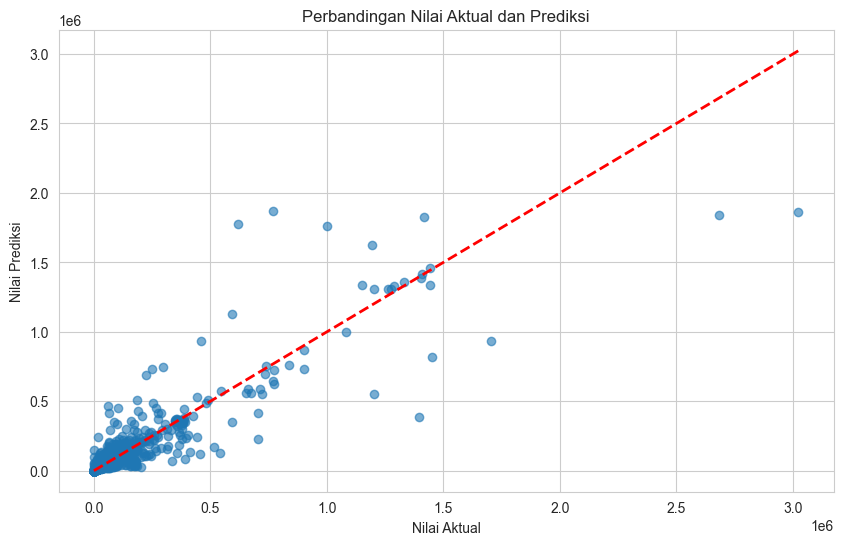

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title('Perbandingan Nilai Aktual dan Prediksi')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')

plt.grid(True)
plt.show()

# Phase 6 Deployment

## Kesimpulan

Berdasarkan hasil analisis menggunakan metode Random Forest Regression, diperoleh model yang mampu melakukan estimasi Total Pembayaran pada transaksi e-commerce dengan baik.

Model dibangun menggunakan beberapa variabel transaksi, yaitu total_qty, total_weight_gr, total_returned_qty, Total Diskon, num_product_categories, Perkiraan Ongkos Kirim, Ongkos Kirim Dibayar oleh Pembeli, Estimasi Potongan Biaya Pengiriman, Status Pesanan, Metode Pembayaran, dan Provinsi.

Hasil evaluasi menunjukkan nilai:

- MAE : 14.204,85
- RMSE : 59.983,17
- R² : 0,8022 (80,2%)

Nilai R² sebesar 80,2% menunjukkan bahwa model mampu menjelaskan sekitar 80,2% variasi pada Total Pembayaran berdasarkan variabel yang digunakan dalam penelitian.

Berdasarkan kriteria keberhasilan yang ditetapkan sebesar 80%, model yang dibangun telah memenuhi target evaluasi dan memiliki performa yang baik dalam melakukan estimasi Total Pembayaran.

Dengan demikian, metode Random Forest Regression dapat digunakan sebagai alat bantu dalam menganalisis transaksi e-commerce serta mendukung pengambilan keputusan berdasarkan data.

In [29]:
print("Model Random Forest Regression berhasil dibangun dan dapat digunakan untuk mengestimasi Total Pembayaran berdasarkan variabel transaksi e-commerce.")

Model Random Forest Regression berhasil dibangun dan dapat digunakan untuk mengestimasi Total Pembayaran berdasarkan variabel transaksi e-commerce.
